In [12]:
import pandas as pd
import numpy as np

df2 = pd.read_csv('Feature_Engineered_train.csv', keep_default_na=False)

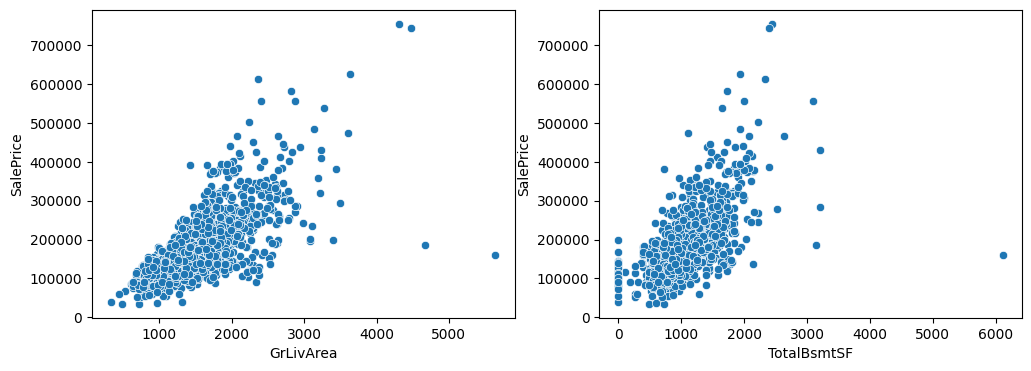

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check the two most important numeric features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df2, x='GrLivArea', y='SalePrice', ax=axes[0])
sns.scatterplot(data=df2, x='TotalBsmtSF', y='SalePrice', ax=axes[1])
plt.show()

In [14]:
#this shows the outliers that need to be deleted:
#GrLivArea > 4500 (with SalePrice < 300000)
#TotalBsmtSF > 4000

In [15]:
def Feature_Encoding(df2):
    df2 = df2.copy()
    
    qual_map = {'None': 0, 'Po': 1, 'Other': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
    ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                    'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual']
    
    for col in ordinal_cols:
        df2[col] = df2[col].map(qual_map)
    
    categorical_cols = df2.select_dtypes(include='object').columns.tolist()
    nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]
    
    df2 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)
    
    #remove outliers (explanation below)
    df2 = df2[~((df2['GrLivArea'] > 4500) & (df2['SalePrice'] < 300000))]
    df22 = df2[df2['TotalBsmtSF'] < 4000]

    return df2

df2 = Feature_Encoding(df2)
df2.to_csv('Feature_Encoded_data.csv')

In [16]:
df2.columns[df2.isnull().any()].to_list()

[]